# 02 — Spatial Domain Filtering
## Smart City Surveillance System — CS 406 Digital Image Processing CCP

**Requires:** `01_preprocessing.ipynb` must be run first — this notebook loads the processed and noisy datasets directly from Google Drive.

Implements Mean, Median, and Laplacian filters (both from-scratch and vectorized), then evaluates them with PSNR/SSIM.

## Step 1 — Mount Google Drive and set paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_DIR = '/content/drive/MyDrive/smart-city-surveillance-dip'
PROCESSED_DIR = Path(f'{PROJECT_DIR}/data/processed')
NOISY_DIR = Path(f'{PROJECT_DIR}/data/noisy')

assert PROCESSED_DIR.exists(), 'Run 01_preprocessing.ipynb first — processed data not found in Drive.'
assert NOISY_DIR.exists(), 'Run 01_preprocessing.ipynb first — noisy data not found in Drive.'
print('Data found. Ready to proceed.')

Mounted at /content/drive
Data found. Ready to proceed.


## Step 2 — Imports and metrics helper functions

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def compute_psnr(original, processed):
    return psnr(original, processed, data_range=255)

def compute_ssim(original, processed):
    return ssim(original, processed, channel_axis=-1 if original.ndim == 3 else None, data_range=255)

def compute_iou(pred_mask, gt_mask):
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    union = np.logical_or(pred_mask, gt_mask).sum()
    return intersection / union if union != 0 else 0

def compute_dice(pred_mask, gt_mask):
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    return (2 * intersection) / (pred_mask.sum() + gt_mask.sum()) if (pred_mask.sum() + gt_mask.sum()) != 0 else 0

## Step 3 — Filters implemented FROM SCRATCH
Required for the CCP: demonstrates understanding of the kernel math, not just library calls. Include this code in your report's methodology/appendix section.

In [ ]:
def mean_filter_scratch(img, kernel_size=3):
    """Mean filter implemented manually via convolution."""
    pad = kernel_size // 2
    padded = np.pad(img, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
    output = np.zeros_like(img, dtype=np.float32)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            for c in range(img.shape[2]):
                region = padded[i:i+kernel_size, j:j+kernel_size, c]
                output[i, j, c] = np.mean(region)
    return np.clip(output, 0, 255).astype(np.uint8)

def median_filter_scratch(img, kernel_size=3):
    """Median filter implemented manually."""
    pad = kernel_size // 2
    padded = np.pad(img, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
    output = np.zeros_like(img, dtype=np.float32)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            for c in range(img.shape[2]):
                region = padded[i:i+kernel_size, j:j+kernel_size, c]
                output[i, j, c] = np.median(region)
    return np.clip(output, 0, 255).astype(np.uint8)

def laplacian_filter_scratch(img):
    """Laplacian filter for edge/detail enhancement, implemented manually."""
    kernel = np.array([[0, 1, 0],
                        [1, -4, 1],
                        [0, 1, 0]])
    pad = 1
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    padded = np.pad(gray, ((pad, pad), (pad, pad)), mode='reflect')
    output = np.zeros_like(gray)
    for i in range(gray.shape[0]):
        for j in range(gray.shape[1]):
            region = padded[i:i+3, j:j+3]
            output[i, j] = np.sum(region * kernel)
    output = np.clip(np.abs(output), 0, 255).astype(np.uint8)
    return cv2.cvtColor(output, cv2.COLOR_GRAY2BGR)

## Step 4 — Sanity check: run scratch filters on ONE image

Scratch filters time: 9.3261s


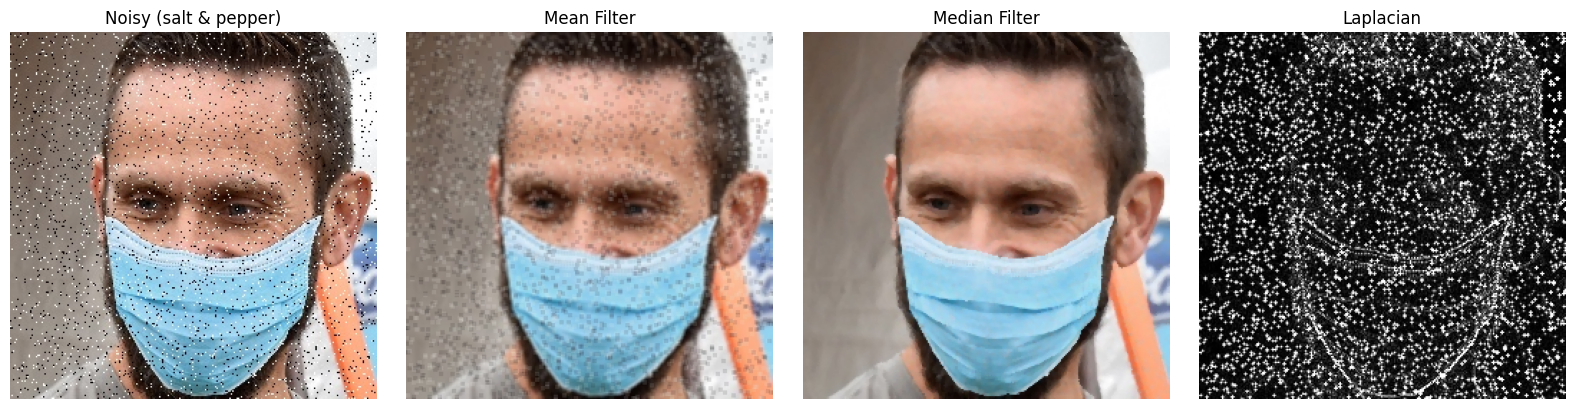

In [ ]:
test_img_path = list((NOISY_DIR / "with_mask").glob("*_saltpepper.jpg"))[0]
test_img = cv2.imread(str(test_img_path))

start = time.time()
mean_result = mean_filter_scratch(test_img, kernel_size=3)
median_result = median_filter_scratch(test_img, kernel_size=3)
laplacian_result = laplacian_filter_scratch(test_img)
print(f"Scratch filters time: {time.time()-start:.4f}s")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ["Noisy (salt & pepper)", "Mean Filter", "Median Filter", "Laplacian"]
images = [test_img, mean_result, median_result, laplacian_result]
for ax, title, im in zip(axes, titles, images):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/figures/filter_comparison_example.png', dpi=150)
plt.show()

**Note for your report's Discussion section:** the Laplacian result looks noisy/messy here because Laplacian is a second-derivative operator — it amplifies noise rather than suppressing it. The correct pipeline is denoise first (median filter), then apply Laplacian for edge enhancement, not apply it directly to raw noisy input.

## Step 5 — Vectorized filters for bulk processing
Same math, ~100x faster. Used for the full quantitative evaluation across the dataset.

In [ ]:
from scipy.ndimage import uniform_filter, median_filter, laplace

def mean_filter_fast(img, kernel_size=3):
    return np.stack([
        uniform_filter(img[:,:,c], size=kernel_size) for c in range(img.shape[2])
    ], axis=2).astype(np.uint8)

def median_filter_fast(img, kernel_size=3):
    return np.stack([
        median_filter(img[:,:,c], size=kernel_size) for c in range(img.shape[2])
    ], axis=2).astype(np.uint8)

def laplacian_filter_fast(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    edge = np.clip(np.abs(laplace(gray)), 0, 255).astype(np.uint8)
    return cv2.cvtColor(edge, cv2.COLOR_GRAY2BGR)

start = time.time()
mean_fast = mean_filter_fast(test_img)
median_fast = median_filter_fast(test_img)
laplacian_fast = laplacian_filter_fast(test_img)
print(f"Vectorized time: {time.time()-start:.4f}s")

Vectorized time: 0.0554s


## Step 6 — Full evaluation: PSNR/SSIM across the dataset
Runs mean & median filters against 30 sampled images per (class × noise type) combination.

In [ ]:
results = []
noise_types = ["gaussian", "saltpepper", "blur"]
class_names = ["with_mask", "without_mask", "incorrect_mask"]

for class_name in class_names:
    clean_dir = PROCESSED_DIR / class_name
    noisy_dir = NOISY_DIR / class_name
    for noise_type in noise_types:
        noisy_files = sorted(noisy_dir.glob(f"*_{noise_type}.jpg"))[:30]
        for noisy_path in noisy_files:
            clean_name = noisy_path.stem.replace(f"_{noise_type}", "") + ".jpg"
            clean_path = clean_dir / clean_name
            if not clean_path.exists():
                continue
            clean_img = cv2.imread(str(clean_path))
            noisy_img = cv2.imread(str(noisy_path))
            mean_out = mean_filter_fast(noisy_img)
            median_out = median_filter_fast(noisy_img)
            results.append({
                "class": class_name, "noise_type": noise_type, "filter": "none",
                "psnr": compute_psnr(clean_img, noisy_img), "ssim": compute_ssim(clean_img, noisy_img)
            })
            results.append({
                "class": class_name, "noise_type": noise_type, "filter": "mean",
                "psnr": compute_psnr(clean_img, mean_out), "ssim": compute_ssim(clean_img, mean_out)
            })
            results.append({
                "class": class_name, "noise_type": noise_type, "filter": "median",
                "psnr": compute_psnr(clean_img, median_out), "ssim": compute_ssim(clean_img, median_out)
            })

df = pd.DataFrame(results)
df.to_csv(f'{PROJECT_DIR}/results/tables/spatial_filtering_results.csv', index=False)
summary = df.groupby(["noise_type", "filter"])[["psnr", "ssim"]].mean().round(3)
summary.to_csv(f'{PROJECT_DIR}/results/tables/spatial_filtering_summary.csv')
print(summary)

                     psnr   ssim
noise_type filter               
blur       mean    26.487  0.752
           median  26.615  0.756
           none    26.684  0.762
gaussian   mean    28.228  0.715
           median  27.842  0.672
           none    23.497  0.448
saltpepper mean    25.242  0.580
           median  33.496  0.907
           none    17.683  0.339


---
**Phase 3 complete.** Results saved to Drive:
- `results/figures/filter_comparison_example.png`
- `results/tables/spatial_filtering_results.csv` (raw per-image results)
- `results/tables/spatial_filtering_summary.csv` (averaged summary — paste this table into your report)

**Next: `03_frequency_filtering.ipynb`** — FFT, frequency-domain low/high-pass filters, and image restoration (inverse & Wiener filtering).

               psnr   ssim
kernel_size               
3            33.431  0.909
5            31.885  0.873
7            30.249  0.835


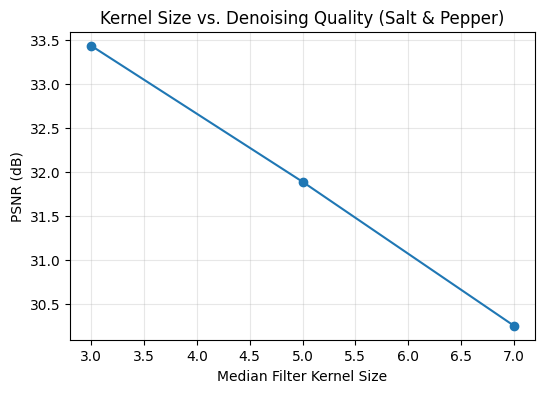

In [ ]:
# ===== Kernel Size Sensitivity Study =====
kernel_results = []
kernel_sizes = [3, 5, 7]

for class_name in class_names:
    clean_dir = PROCESSED_DIR / class_name
    noisy_dir = NOISY_DIR / class_name
    noisy_files = sorted(noisy_dir.glob("*_saltpepper.jpg"))[:20]

    for noisy_path in noisy_files:
        clean_name = noisy_path.stem.replace("_saltpepper", "") + ".jpg"
        clean_path = clean_dir / clean_name
        if not clean_path.exists():
            continue
        clean_img = cv2.imread(str(clean_path))
        noisy_img = cv2.imread(str(noisy_path))

        for k in kernel_sizes:
            median_out = median_filter_fast(noisy_img, kernel_size=k)
            kernel_results.append({
                "class": class_name, "kernel_size": k,
                "psnr": compute_psnr(clean_img, median_out),
                "ssim": compute_ssim(clean_img, median_out)
            })

kernel_df = pd.DataFrame(kernel_results)
kernel_df.to_csv(f'{PROJECT_DIR}/results/tables/kernel_sensitivity_results.csv', index=False)
kernel_summary = kernel_df.groupby("kernel_size")[["psnr", "ssim"]].mean().round(3)
kernel_summary.to_csv(f'{PROJECT_DIR}/results/tables/kernel_sensitivity_summary.csv')
print(kernel_summary)

plt.figure(figsize=(6,4))
plt.plot(kernel_summary.index, kernel_summary['psnr'], 'o-', label='PSNR')
plt.xlabel("Median Filter Kernel Size")
plt.ylabel("PSNR (dB)")
plt.title("Kernel Size vs. Denoising Quality (Salt & Pepper)")
plt.grid(alpha=0.3)
plt.savefig(f'{PROJECT_DIR}/results/figures/kernel_sensitivity.png', dpi=150)
plt.show()